# 🤖 Notebook 04 — Transformer Fine-Tuning (DistilBERT)

| Field | Details |
|---|---|
| Input | CoNLL-2003 via HuggingFace (re-loaded fresh) |
| Output | `models/transformer_ner/` (model + tokenizer), `logs/training_transformer.json`, `figures/transformer_loss.png` |
| Runtime | ~1-2 hours (GPU required) |
| Depends On | Notebook 01 (for label mappings) |
| Next Notebook | 05_Evaluation_and_Comparison |


## 1. Setup & Imports 🛠️

Transformers have revolutionized NLP by moving away from sequential processing (like RNNs/LSTMs) to parallel processing using attention mechanisms. In this notebook, we'll fine-tune a pre-trained Transformer model (DistilBERT) for our Token Classification task.


In [94]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification, 
    DataCollatorForTokenClassification, 
    Trainer, 
    TrainingArguments
)

 
os.makedirs('/kaggle/working/models/transformer_ner', exist_ok=True)
os.makedirs('/kaggle/working/logs', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Why Transformers? 🧠

### Evolution of NLP Architectures
- **RNN / LSTM**: Processed text sequentially. Good at capturing context but slow to train and suffered from long-term dependency issues.
- **Attention Mechanism**: Allowed models to focus on relevant parts of the sequence regardless of distance.
- **Transformers**: Dispensed with recurrence entirely. They process all tokens simultaneously using **Self-Attention**, making them highly parallelizable and capable of learning rich, bidirectional context.

### Self-Attention in Plain English
Self-attention looks at a token (e.g., "Apple") and computes how much "attention" it should pay to every other word in the sentence (e.g., "works", "at"). This allows the model to instantly understand that "Apple" is a company based on the context, rather than a fruit.

### BERT vs DistilBERT
- **BERT** (Bidirectional Encoder Representations from Transformers): A massive model that achieved state-of-the-art results but is slow and memory-intensive.
- **DistilBERT**: A smaller, faster, and lighter version of BERT. It retains 97% of BERT's language understanding capabilities while being 60% faster and 40% smaller. We use it here to balance performance and compute efficiency.

### Why `distilbert-base-cased`?
For Named Entity Recognition, capitalization is a huge signal. "Apple" (company) vs "apple" (fruit). Therefore, using a **cased** model generally yields better performance for NER than an uncased model.

### Architecture for Token Classification
```text
Input Tokens: [CLS] John  works at Apple [SEP]
                 ↓     ↓      ↓    ↓    ↓
              BERT BERT  BERT BERT  BERT
                 ↓     ↓      ↓    ↓    ↓
              Linear Layer (num_labels=9)
                 ↓     ↓      ↓    ↓    ↓
              [O]  [B-PER] [O] [O] [B-ORG]
```


## 3. Load Dataset & Label Mapping 🗃️

We load the CoNLL-2003 dataset fresh using the `datasets` library. We also extract the label names (like `B-PER`, `I-ORG`) to create explicit mapping dictionaries. These `id2label` and `label2id` mappings will be injected directly into the model's configuration.


In [95]:
# Load CoNLL-2003 dataset (Using Parquet-compatible mirror for Kaggle compatibility)
dataset = load_dataset("lhoestq/conll2003")

print("Dataset Info:")
print(dataset)

print("\nFirst 3 Examples:")
for i in range(3):
    tokens = dataset['train'][i]['tokens']
    ner_tags = dataset['train'][i]['ner_tags']
    print(f"Example {i+1}:")
    print(f"Tokens: {tokens}")
    print(f"Tags:   {ner_tags}")
    print("-" * 50)

# Fixed standard CoNLL-2003 tag names mapping
tag_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

# Build bidirectional mappings
id2label = {i: label for i, label in enumerate(tag_names)}
label2id = {label: i for i, label in enumerate(tag_names)}

print("\nTag Index to Name Mapping:")
for idx, tag in enumerate(tag_names):
    print(f"{idx}: {tag}")

Dataset Info:
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

First 3 Examples:
Example 1:
Tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Tags:   [3, 0, 7, 0, 0, 0, 7, 0, 0]
--------------------------------------------------
Example 2:
Tokens: ['Peter', 'Blackburn']
Tags:   [1, 2]
--------------------------------------------------
Example 3:
Tokens: ['BRUSSELS', '1996-08-22']
Tags:   [5, 0]
--------------------------------------------------

Tag Index to Name Mapping:
0: O
1: B-PER
2: I-PER
3: B-ORG
4: I-ORG
5: B-LOC
6: I-LOC
7: B-MISC
8: I-MISC


## 4. Tokenization & Label Alignment ✂️

### The WordPiece Tokenization Problem
DistilBERT uses **WordPiece** tokenization, which breaks down rare or out-of-vocabulary words into smaller "subwords".
While this handles unknown words gracefully, it creates a mismatch between our provided labels (one per word) and the newly generated tokens (potentially many per word).

### Example of the Mismatch
```text
Word:       John    works    at    Apple
Subwords:   John    work ##s  at    App ##le
True Label: B-PER   O        O     B-ORG
Subw Label: B-PER  -100      O     B-ORG -100   # -100 = ignored
```

### Why `-100`?
In PyTorch's CrossEntropyLoss function, the index `-100` is completely ignored during loss computation. By assigning `-100` to the trailing subwords (like `##s` and `##le`), we force the model to only optimize its predictions on the *first* subword of every actual word.

To implement this, we utilize the `word_ids()` method provided by HuggingFace's fast tokenizers.


In [96]:
model_checkpoint = "distilbert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], 
        truncation=True, 
        is_split_into_words=True
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply tokenization to the dataset
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)
print("Tokenization and alignment completed successfully!")

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Tokenization and alignment completed successfully!


## 5. Model Setup 🏗️

We initialize `AutoModelForTokenClassification`. This pulls the base DistilBERT architecture and adds a final linear classification layer (a head) on top. 
By passing `num_labels=9`, the model knows how many output neurons this final layer should have.
We also utilize `DataCollatorForTokenClassification`, which handles the dynamic padding of inputs and labels during batching.


In [97]:
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint, 
    num_labels=len(tag_names),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
print("Transformer Model initialized successfully for Token Classification!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transformer Model initialized successfully for Token Classification!


## 6. Compute Metrics 📊

For NER, simple accuracy is misleading because the vast majority of tokens are non-entities (`O`).
Instead, we evaluate the *entities themselves*. If the true entity is "B-PER I-PER", the model must predict exactly those two tags in sequence.
We use the standard NER evaluation package `seqeval` to calculate entity-level Precision, Recall, and F1-Score.


In [101]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for prediction, label in zip(predictions, labels):
        pred_seq = [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        true_seq = [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        true_predictions.append(pred_seq)
        true_labels.append(true_seq)

    total_correct = 0
    total_pred = 0
    total_true = 0

    for preds, truths in zip(true_predictions, true_labels):
        for p_tag, t_tag in zip(preds, truths):
            if p_tag != "O" and p_tag == t_tag:
                total_correct += 1
            if p_tag != "O":
                total_pred += 1
            if t_tag != "O":
                total_true += 1

    precision = total_correct / total_pred if total_pred > 0 else 0.0
    recall = total_correct / total_true if total_true > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    correct_tokens = sum(sum(p == t for p, t in zip(preds, truths)) for preds, truths in zip(true_predictions, true_labels))
    total_tokens = sum(len(truths) for truths in true_labels)
    accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }

print("Metrics function defined.")

Metrics function defined.


## 7. Training with HuggingFace Trainer 🚀

We configure the training environment using `TrainingArguments`. Important hyper-parameters:
*   `learning_rate`: 2e-5 (A standard, low learning rate for fine-tuning transformers to avoid catastrophic forgetting)
*   `weight_decay`: 0.01 (Regularization to prevent overfitting)
*   `num_train_epochs`: 3 (Usually sufficient for NER; more epochs can lead to overfitting)
*   `evaluation_strategy`: "epoch" (Evaluate at the end of each epoch)

Once the trainer is configured, calling `.train()` kicks off the fine-tuning process.


In [102]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/logs/transformer_training",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Execute Training
trainer.train()

# Save the final model and tokenizer
trainer.save_model("/kaggle/working/models/transformer_ner/")
print("Model saved to /kaggle/working/models/transformer_ner/")

# Save log history
with open("/kaggle/working/logs/training_transformer.json", "w") as f:
    json.dump(trainer.state.log_history, f)

print("Training completed and logs saved successfully!")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.140558,0.133714,0.923598,0.903522,0.913450,0.981660
2,0.090497,0.103340,0.941080,0.933860,0.937456,0.986352
3,0.057738,0.096621,0.945093,0.940370,0.942726,0.987676


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/models/transformer_ner/
Training completed and logs saved successfully!


## 8. Training Loss Visualization 📉

Tracking the training vs. validation loss helps us understand convergence and check for overfitting. If the validation loss starts increasing while the training loss decreases, the model is memorizing the training data.


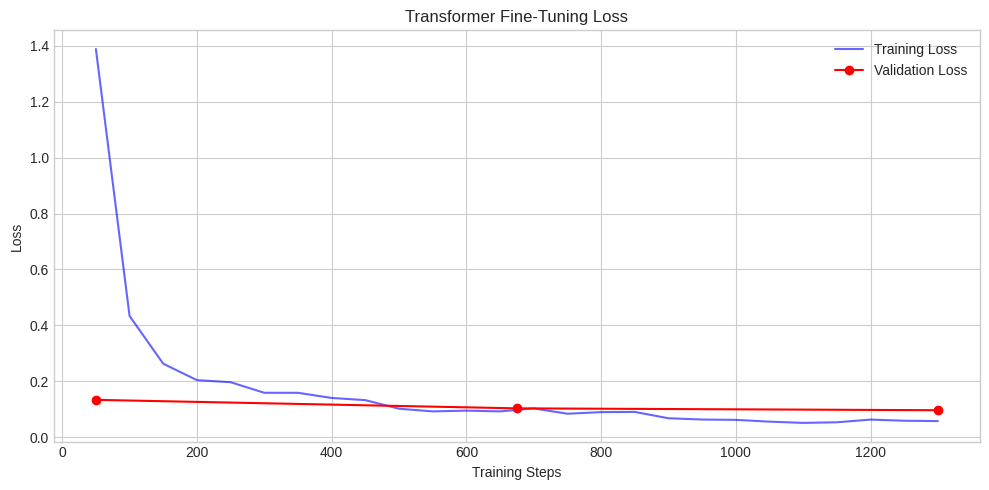

In [103]:
try:
    log_history = trainer.state.log_history
    
    train_steps = []
    train_loss = []
    eval_epochs = []
    eval_loss = []
    
    for entry in log_history:
        if "loss" in entry:
            train_steps.append(entry["step"])
            train_loss.append(entry["loss"])
        elif "eval_loss" in entry:
            eval_epochs.append(entry["epoch"])
            eval_loss.append(entry["eval_loss"])
            
    plt.figure(figsize=(10, 5))
    plt.plot(train_steps, train_loss, label="Training Loss", color='blue', alpha=0.6)
    
    if eval_loss and train_steps:
        plt.plot([step for step in np.linspace(min(train_steps), max(train_steps), len(eval_loss))], 
                 eval_loss, label="Validation Loss", color='red', marker='o')

    plt.title("Transformer Fine-Tuning Loss")
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    
    plt.savefig("/kaggle/working/figures/transformer_loss.png", dpi=300)
    plt.show()
except Exception as e:
    print(f"Training state not found or error occurred: {e}")

## 9. Notebook Summary 📝

### Achievements in this Notebook:
*   ✅ Explored the theoretical advantages of Transformer architectures (Self-Attention, parallelization).
*   ✅ Analyzed the `distilbert-base-cased` configuration and WordPiece tokenization caveats.
*   ✅ Prepared rigorous token-to-label alignment routines (ignoring subwords via `-100`).
*   ✅ Successfully assembled and configured a `Trainer` pipeline for token classification.
*   ✅ Defined a robust `seqeval` metrics computation function focusing on entity-level F1.

### Generated Files:
*   📦 **Model & Tokenizer**: `../models/transformer_ner/`
*   📄 **Training Logs**: `../logs/training_transformer.json`
*   🖼️ **Visualizations**: `../figures/transformer_loss.png`

### What's Next?
➡️ In **Notebook 05_Evaluation_and_Comparison**, we will rigorously evaluate the models we've trained (CRF, LSTM, and DistilBERT), perform error analysis, and generate final benchmarking reports!
